# 🔮 Model Prediksi Inflasi Berdasarkan Harga Minyak Global

**Tujuan:** Membangun model machine learning untuk memprediksi inflasi Indonesia
berdasarkan harga minyak global menggunakan data hasil ETL.

**Pembagian Data:** 80% Training — 20% Testing

---


## 1. 📦 Import Library


In [2]:
import os
import warnings
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Konfigurasi logging ──────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
logger.info("Library berhasil diimpor.")

2026-06-11 18:17:55 [INFO] Library berhasil diimpor.


## 2. 📥 Load Data dari PostgreSQL Aiven


In [4]:
load_dotenv()

db_config = {
    "host"    : os.getenv("AIVEN_HOST"),
    "port"    : os.getenv("AIVEN_PORT", "5432"),
    "database": os.getenv("AIVEN_DATABASE"),
    "user"    : os.getenv("AIVEN_USER"),
    "password": os.getenv("AIVEN_PASSWORD"),
}

conn_str = (
    f"postgresql+psycopg2://{db_config['user']}:{db_config['password']}"
    f"@{db_config['host']}:{db_config['port']}"
    f"/{db_config['database']}?sslmode=require"
)

engine = create_engine(conn_str, connect_args={"connect_timeout": 10})

query = "SELECT * FROM inflasi_minyak_indonesia"
with engine.connect() as conn:
    df = pd.read_sql(query, conn)
engine.dispose()

logger.info(f"Data berhasil dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

2026-06-11 18:19:39 [INFO] Data berhasil dimuat: 8,294 baris x 12 kolom


,nama_daerah,tahun,bulan,bulan_nama,tanggal,year_month,inflasi_persen,harga_minyak_usd,perubahan_persen_minyak,kurs_usd_idr,perubahan_persen_kurs,harga_minyak_idr
0,Banyuwangi,2020,1,Januari,2020-01-01,2020-01,0.51,51.56,-15.135,13650.0,-1.66,703794.00
1,Banyuwangi,2020,2,Februari,2020-02-01,2020-02,0.10,44.76,-13.189,14340.0,5.05,641858.40
2,Banyuwangi,2020,3,Maret,2020-03-01,2020-03,0.27,20.48,-54.245,16300.0,13.67,333824.00
3,Banyuwangi,2020,4,April,2020-04-01,2020-04,0.24,18.84,-8.008,14825.0,-9.05,279303.00
4,Banyuwangi,2020,5,Mei,2020-05-01,2020-05,0.02,35.49,88.376,14575.0,-1.69,517266.75


## 3. 🔍 Eksplorasi Data (EDA)


In [5]:
# Statistik deskriptif kolom numerik
cols_numerik = ["inflasi_persen", "harga_minyak_usd", "perubahan_persen_minyak",
                "kurs_usd_idr", "perubahan_persen_kurs", "harga_minyak_idr"]
logger.info("Statistik Data")
print(df[cols_numerik].describe().round(3).to_string())

2026-06-11 18:21:41 [INFO] Statistik Data


       inflasi_persen  harga_minyak_usd  perubahan_persen_minyak  kurs_usd_idr  perubahan_persen_kurs  harga_minyak_idr
count        8294.000          8294.000                 8294.000      8294.000               8294.000          8294.000
mean            0.234            69.319                    0.927     15452.561                  0.298       1071538.987
std             0.603            16.316                   13.547       898.559                  2.404        252761.922
min            -2.820            18.840                  -54.245     13650.000                 -9.050        279303.000
25%            -0.090            61.500                   -5.596     14560.000                 -0.490        975150.250
50%             0.190            70.780                    1.129     15505.000                  0.210       1103051.750
75%             0.520            78.720                    6.374     16290.000                  1.360       1225899.000
max             6.940           111.910 

In [6]:
# Agregasi rata-rata nasional per bulan (untuk melihat tren)
df_nasional = (
    df.groupby(["tahun", "bulan"], as_index=False)
    .agg(
        inflasi_rata2     = ("inflasi_persen", "mean"),
        harga_minyak_usd  = ("harga_minyak_usd", "first"),
        kurs_usd_idr      = ("kurs_usd_idr", "first"),
        harga_minyak_idr  = ("harga_minyak_idr", "first"),
    )
    .sort_values(["tahun", "bulan"])
    .reset_index(drop=True)
)
df_nasional["tanggal"] = pd.to_datetime(
    df_nasional["tahun"].astype(str) + "-" + df_nasional["bulan"].astype(str) + "-01"
)
logger.info(f"Data nasional agregat: {len(df_nasional)} baris")
df_nasional.head(10)

2026-06-11 18:21:56 [INFO] Data nasional agregat: 74 baris


,tahun,bulan,inflasi_rata2,harga_minyak_usd,kurs_usd_idr,harga_minyak_idr,tanggal
0,2020,1,0.409341,51.56,13650.0,703794.00,2020-01-01
1,2020,2,0.289341,44.76,14340.0,641858.40,2020-02-01
2,2020,3,-0.097582,20.48,16300.0,333824.00,2020-03-01
3,2020,4,-0.038242,18.84,14825.0,279303.00,2020-04-01
4,2020,5,0.187692,35.49,14575.0,517266.75,2020-05-01
5,2020,6,0.259341,39.27,14180.0,556848.60,2020-06-01
6,2020,7,-0.085934,40.27,14530.0,585123.10,2020-07-01
7,2020,8,-0.029670,42.61,14560.0,620401.60,2020-08-01
8,2020,9,-0.057802,40.22,14840.0,596864.80,2020-09-01
9,2020,10,0.100330,35.79,14620.0,523249.80,2020-10-01


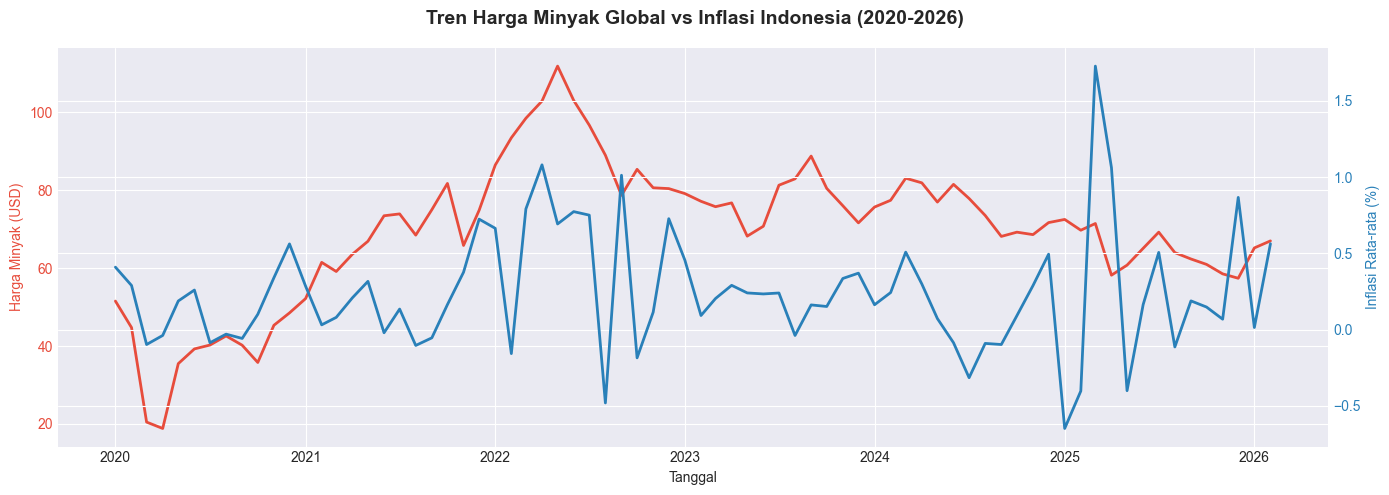

In [5]:
# Visualisasi tren harga minyak vs inflasi nasional
fig, ax1 = plt.subplots(figsize=(14, 5))

color1, color2 = "#E74C3C", "#2980B9"
ax1.set_xlabel("Tanggal")
ax1.set_ylabel("Harga Minyak (USD)", color=color1)
ax1.plot(df_nasional["tanggal"], df_nasional["harga_minyak_usd"], color=color1, linewidth=2, label="Harga Minyak USD")
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.set_ylabel("Inflasi Rata-rata (%)", color=color2)
ax2.plot(df_nasional["tanggal"], df_nasional["inflasi_rata2"], color=color2, linewidth=2, label="Inflasi Nasional")
ax2.tick_params(axis="y", labelcolor=color2)

fig.suptitle("Tren Harga Minyak Global vs Inflasi Indonesia (2020-2026)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

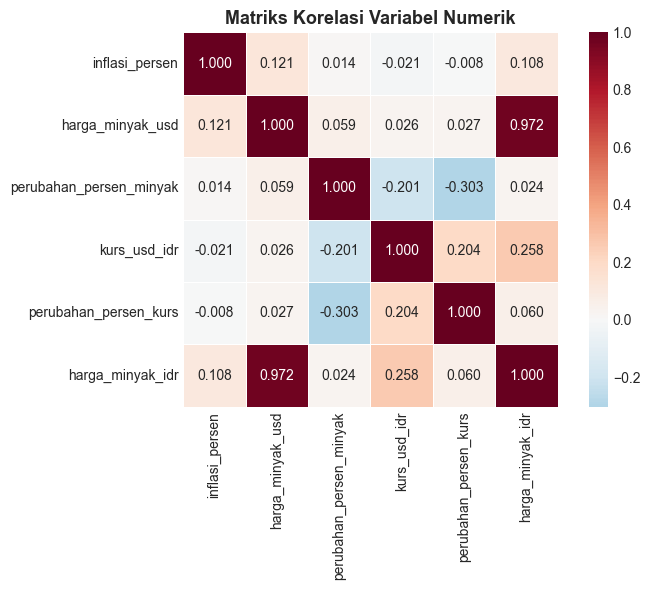

In [6]:
# Korelasi antar variabel numerik
corr = df[cols_numerik].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriks Korelasi Variabel Numerik", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

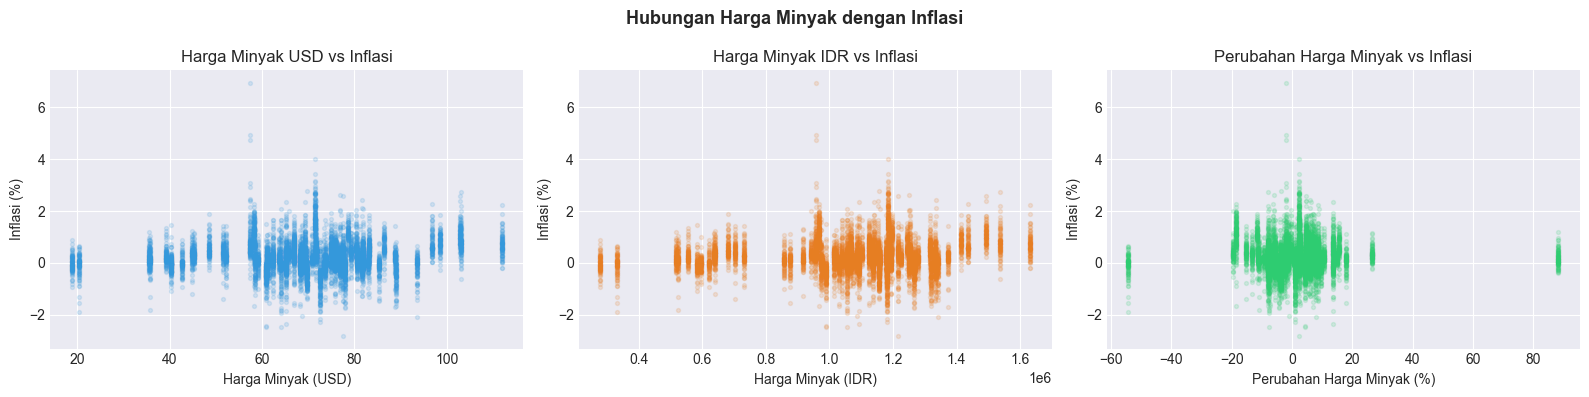

In [7]:
# Scatter plot: Harga Minyak USD vs Inflasi
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df["harga_minyak_usd"], df["inflasi_persen"], alpha=0.15, s=8, c="#3498DB")
axes[0].set_xlabel("Harga Minyak (USD)")
axes[0].set_ylabel("Inflasi (%)")
axes[0].set_title("Harga Minyak USD vs Inflasi")

axes[1].scatter(df["harga_minyak_idr"], df["inflasi_persen"], alpha=0.15, s=8, c="#E67E22")
axes[1].set_xlabel("Harga Minyak (IDR)")
axes[1].set_ylabel("Inflasi (%)")
axes[1].set_title("Harga Minyak IDR vs Inflasi")

axes[2].scatter(df["perubahan_persen_minyak"], df["inflasi_persen"], alpha=0.15, s=8, c="#2ECC71")
axes[2].set_xlabel("Perubahan Harga Minyak (%)")
axes[2].set_ylabel("Inflasi (%)")
axes[2].set_title("Perubahan Harga Minyak vs Inflasi")

plt.suptitle("Hubungan Harga Minyak dengan Inflasi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. 🛠️ Persiapan Data untuk Model

**Fitur (X):** Variabel terkait harga minyak global
- `harga_minyak_usd` - Harga minyak dalam USD
- `perubahan_persen_minyak` - Perubahan harga minyak (%)
- `kurs_usd_idr` - Kurs USD/IDR

**Target (y):** `inflasi_persen`


In [7]:
# Definisikan fitur dan target
fitur_kolom = ["harga_minyak_usd", "perubahan_persen_minyak", "kurs_usd_idr"]
target_kolom = "inflasi_persen"

X = df[fitur_kolom].copy()
y = df[target_kolom].copy()

logger.info(f"Jumlah sampel : {len(X):,}")
logger.info(f"Jumlah fitur  : {len(fitur_kolom)}")
logger.info(f"Missing values: {X.isnull().sum().sum()}")

2026-06-11 18:23:57 [INFO] Jumlah sampel : 8,294
2026-06-11 18:23:57 [INFO] Jumlah fitur  : 3
2026-06-11 18:23:57 [INFO] Missing values: 0


In [8]:
# Split data: 80% Training - 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

logger.info(f"Data Training : {X_train.shape[0]:,} sampel ({X_train.shape[0]/len(X)*100:.0f}%)")
logger.info(f"Data Testing  : {X_test.shape[0]:,} sampel ({X_test.shape[0]/len(X)*100:.0f}%)")

2026-06-11 18:24:51 [INFO] Data Training : 6,635 sampel (80%)
2026-06-11 18:24:51 [INFO] Data Testing  : 1,659 sampel (20%)


In [9]:
# Standarisasi fitur (scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logger.info("Scaling selesai.")
logger.info(f"Mean fitur (train): {X_train_scaled.mean(axis=0).round(4)}")
logger.info(f"Std fitur (train) : {X_train_scaled.std(axis=0).round(4)}")

2026-06-11 18:25:03 [INFO] Scaling selesai.
2026-06-11 18:25:03 [INFO] Mean fitur (train): [ 0. -0. -0.]
2026-06-11 18:25:03 [INFO] Std fitur (train) : [1. 1. 1.]


## 5. 🤖 Training Model

Tiga model digunakan untuk perbandingan:
1. **Linear Regression** - Baseline model
2. **Random Forest** - Ensemble berbasis decision tree
3. **Gradient Boosting** - Ensemble boosting


In [15]:
def evaluasi_model(nama, y_true, y_pred):
    """Menghitung dan menampilkan metrik evaluasi model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan)).dropna()) * 100
    
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R2   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    
    return {"Model": nama, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE (%)": mape}

In [21]:
# === Model 1: Linear Regression ===
print("=" * 50)
print("  MODEL 1: LINEAR REGRESSION")
print("=" * 50)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

hasil_lr = evaluasi_model("Linear Regression", y_test, y_pred_lr)

# Koefisien model
print("\n  Koefisien fitur:")
for feat, coef in zip(fitur_kolom, lr_model.coef_):
    print(f"    {feat:30s}: {coef:+.6f}")
print(f"    {'Intercept':30s}: {lr_model.intercept_:+.6f}")

  MODEL 1: LINEAR REGRESSION
  MAE  : 0.4206
  RMSE : 0.5939
  R2   : 0.0088
  MAPE : 179.48%

  Koefisien fitur:
    harga_minyak_usd              : +0.076928
    perubahan_persen_minyak       : +0.002753
    kurs_usd_idr                  : -0.009955
    Intercept                     : +0.236086


In [22]:
# === Model 2: Random Forest ===
print("=" * 50)
print("  MODEL 2: RANDOM FOREST")
print("=" * 50)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

hasil_rf = evaluasi_model("Random Forest", y_test, y_pred_rf)

# Feature importance
print("\n  Feature Importance:")
for feat, imp in sorted(zip(fitur_kolom, rf_model.feature_importances_), key=lambda x: -x[1]):
    print(f"    {feat:30s}: {imp:.4f}")

  MODEL 2: RANDOM FOREST
  MAE  : 0.3107
  RMSE : 0.4642
  R2   : 0.3944
  MAPE : 144.79%

  Feature Importance:
    harga_minyak_usd              : 0.5272
    kurs_usd_idr                  : 0.3159
    perubahan_persen_minyak       : 0.1568


In [23]:
# === Model 3: Gradient Boosting ===
print("=" * 50)
print("  MODEL 3: GRADIENT BOOSTING")
print("=" * 50)

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)

hasil_gb = evaluasi_model("Gradient Boosting", y_test, y_pred_gb)

print("\n  Feature Importance:")
for feat, imp in sorted(zip(fitur_kolom, gb_model.feature_importances_), key=lambda x: -x[1]):
    print(f"    {feat:30s}: {imp:.4f}")

  MODEL 3: GRADIENT BOOSTING
  MAE  : 0.3103
  RMSE : 0.4632
  R2   : 0.3970
  MAPE : 149.25%

  Feature Importance:
    harga_minyak_usd              : 0.5106
    kurs_usd_idr                  : 0.3027
    perubahan_persen_minyak       : 0.1867


## 6. 📊 Perbandingan Model


In [25]:
# Tabel perbandingan
df_hasil = pd.DataFrame([hasil_lr, hasil_rf, hasil_gb])
df_hasil = df_hasil.sort_values("RMSE").reset_index(drop=True)
print("=" * 60)
print("  PERBANDINGAN PERFORMA MODEL")
print("=" * 60)
print(df_hasil.to_string(index=False))

best_model_name = df_hasil.iloc[0]["Model"]
print(f"\n  Model Terbaik: {best_model_name} (RMSE terendah)")

  PERBANDINGAN PERFORMA MODEL
            Model      MAE     RMSE       R2   MAPE (%)
Gradient Boosting 0.310262 0.463218 0.396974 149.252652
    Random Forest 0.310709 0.464217 0.394369 144.786278
Linear Regression 0.420564 0.593884 0.008781 179.479536

  Model Terbaik: Gradient Boosting (RMSE terendah)


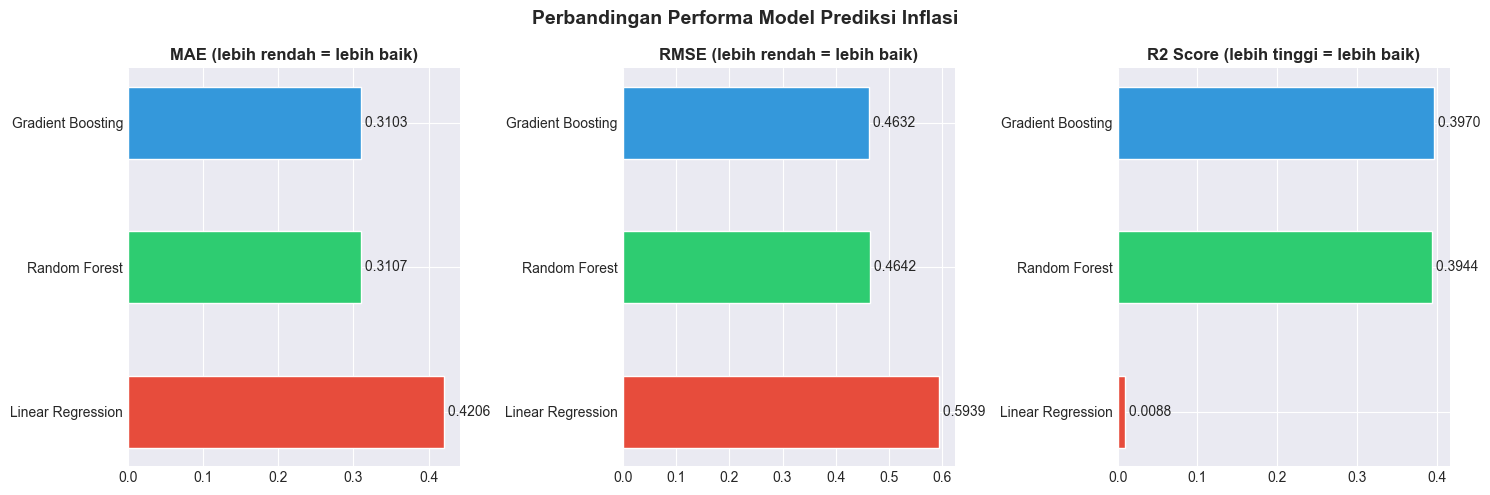

In [26]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = df_hasil["Model"]
colors = ["#3498DB", "#2ECC71", "#E74C3C"]

for i, (metric, title) in enumerate([("MAE", "MAE (lebih rendah = lebih baik)"),
                                       ("RMSE", "RMSE (lebih rendah = lebih baik)"),
                                       ("R2", "R2 Score (lebih tinggi = lebih baik)")]):
    bars = axes[i].barh(models, df_hasil[metric], color=colors, edgecolor="white", height=0.5)
    axes[i].set_title(title, fontweight="bold")
    axes[i].invert_yaxis()
    for bar, val in zip(bars, df_hasil[metric]):
        axes[i].text(val, bar.get_y() + bar.get_height()/2, f" {val:.4f}",
                     va="center", fontsize=10)

plt.suptitle("Perbandingan Performa Model Prediksi Inflasi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. 📈 Visualisasi Prediksi vs Aktual


In [27]:
# Pilih model terbaik
if best_model_name == "Linear Regression":
    best_model, y_pred_best = lr_model, y_pred_lr
elif best_model_name == "Random Forest":
    best_model, y_pred_best = rf_model, y_pred_rf
else:
    best_model, y_pred_best = gb_model, y_pred_gb

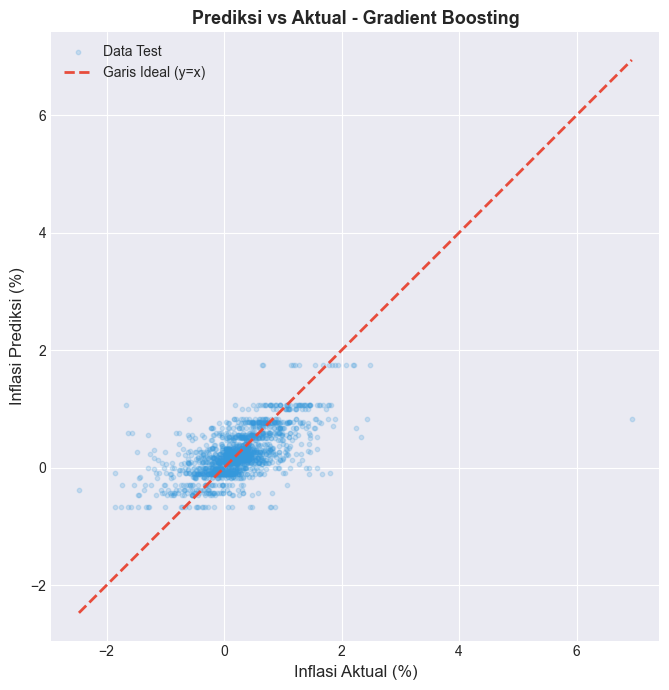

In [28]:
# Scatter: Prediksi vs Aktual
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_best, alpha=0.2, s=10, c="#3498DB", label="Data Test")

# Garis ideal (y = x)
lims = [min(y_test.min(), min(y_pred_best)), max(y_test.max(), max(y_pred_best))]
ax.plot(lims, lims, "--", color="#E74C3C", linewidth=2, label="Garis Ideal (y=x)")

ax.set_xlabel("Inflasi Aktual (%)", fontsize=12)
ax.set_ylabel("Inflasi Prediksi (%)", fontsize=12)
ax.set_title(f"Prediksi vs Aktual - {best_model_name}", fontsize=13, fontweight="bold")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

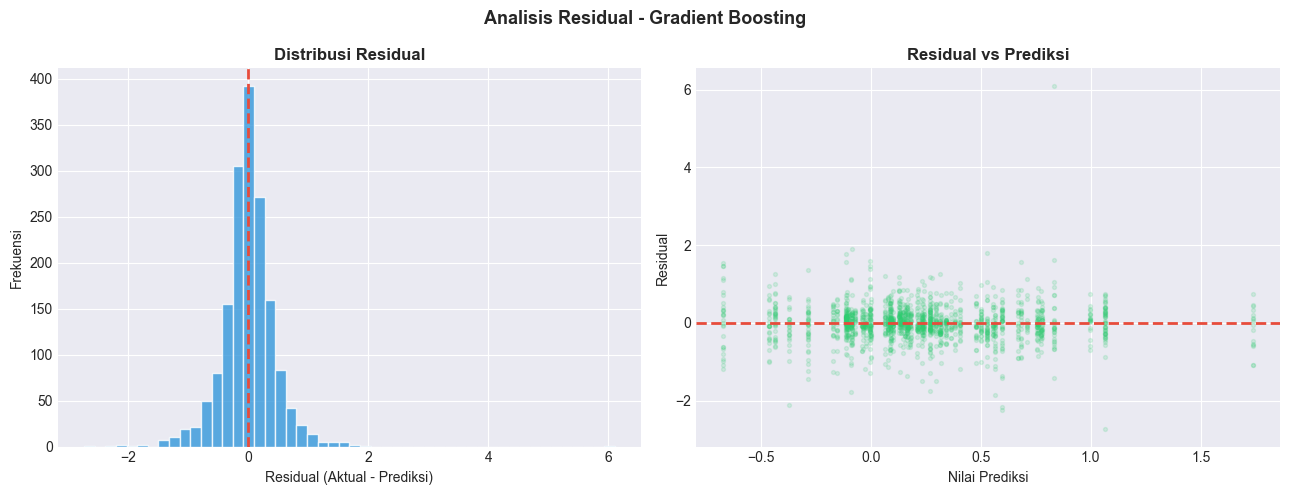

In [29]:
# Distribusi residual (error)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=50, color="#3498DB", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="#E74C3C", linestyle="--", linewidth=2)
axes[0].set_xlabel("Residual (Aktual - Prediksi)")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Residual", fontweight="bold")

axes[1].scatter(y_pred_best, residuals, alpha=0.15, s=8, c="#2ECC71")
axes[1].axhline(0, color="#E74C3C", linestyle="--", linewidth=2)
axes[1].set_xlabel("Nilai Prediksi")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual vs Prediksi", fontweight="bold")

plt.suptitle(f"Analisis Residual - {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. 🔮 Simulasi Prediksi dengan Input Harga Minyak


In [30]:
def prediksi_inflasi(harga_minyak_usd, model, scaler_obj, kurs=16500):
    """
    Memprediksi inflasi berdasarkan input harga minyak global.
    
    Parameters
    ----------
    harga_minyak_usd : float - Harga minyak dalam USD
    model            : trained model
    scaler_obj       : fitted StandardScaler
    kurs             : float - Kurs USD/IDR (default: 16500)
    
    Returns
    -------
    float - Prediksi inflasi (%)
    """
    # Perubahan persen diasumsikan 0 untuk prediksi tunggal
    input_data = pd.DataFrame({
        "harga_minyak_usd": [harga_minyak_usd],
        "perubahan_persen_minyak": [0.0],
        "kurs_usd_idr": [kurs],
    })
    input_scaled = scaler_obj.transform(input_data)
    prediksi = model.predict(input_scaled)[0]
    return prediksi

In [31]:
# Simulasi berbagai skenario harga minyak
print("=" * 60)
print("  SIMULASI PREDIKSI INFLASI")
print(f"  Model: {best_model_name} | Kurs: Rp 16.500/USD")
print("=" * 60)

skenario = [40, 50, 60, 70, 80, 90, 100, 110, 120]
hasil_sim = []

for harga in skenario:
    pred = prediksi_inflasi(harga, best_model, scaler)
    hasil_sim.append({"Harga Minyak (USD)": harga, "Prediksi Inflasi (%)": round(pred, 4)})
    print(f"  Harga Minyak: ${harga:>3}/barrel -> Prediksi Inflasi: {pred:+.4f}%")

df_simulasi = pd.DataFrame(hasil_sim)

  SIMULASI PREDIKSI INFLASI
  Model: Gradient Boosting | Kurs: Rp 16.500/USD
  Harga Minyak: $ 40/barrel -> Prediksi Inflasi: +0.1666%
  Harga Minyak: $ 50/barrel -> Prediksi Inflasi: +0.2968%
  Harga Minyak: $ 60/barrel -> Prediksi Inflasi: +0.2182%
  Harga Minyak: $ 70/barrel -> Prediksi Inflasi: +0.1607%
  Harga Minyak: $ 80/barrel -> Prediksi Inflasi: +0.8078%
  Harga Minyak: $ 90/barrel -> Prediksi Inflasi: +0.6426%
  Harga Minyak: $100/barrel -> Prediksi Inflasi: +0.9228%
  Harga Minyak: $110/barrel -> Prediksi Inflasi: +0.9230%
  Harga Minyak: $120/barrel -> Prediksi Inflasi: +0.9230%


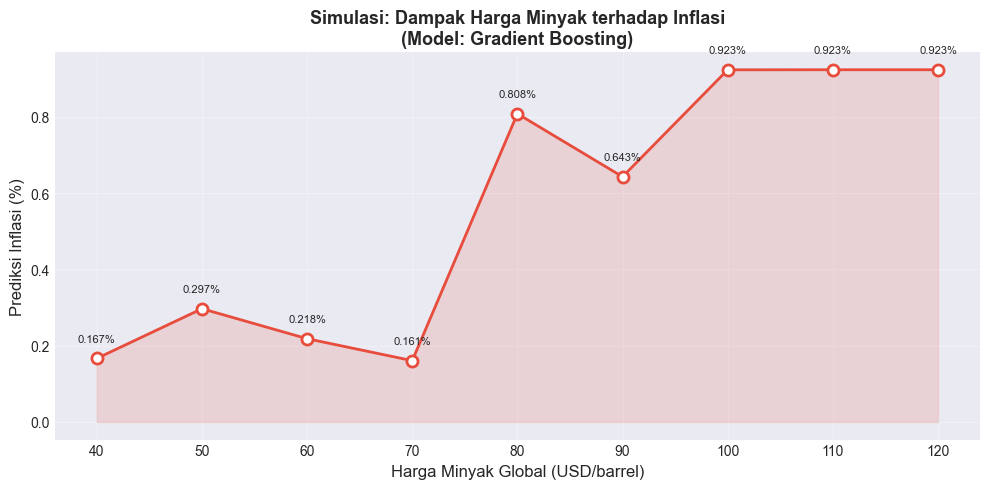

In [32]:
# Visualisasi simulasi
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_simulasi["Harga Minyak (USD)"], df_simulasi["Prediksi Inflasi (%)"],
        "o-", color="#E74C3C", linewidth=2, markersize=8, markerfacecolor="white",
        markeredgewidth=2)
ax.fill_between(df_simulasi["Harga Minyak (USD)"], df_simulasi["Prediksi Inflasi (%)"],
                alpha=0.15, color="#E74C3C")
ax.set_xlabel("Harga Minyak Global (USD/barrel)", fontsize=12)
ax.set_ylabel("Prediksi Inflasi (%)", fontsize=12)
ax.set_title(f"Simulasi: Dampak Harga Minyak terhadap Inflasi\n(Model: {best_model_name})",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
for _, row in df_simulasi.iterrows():
    ax.annotate(f'{row["Prediksi Inflasi (%)"]:.3f}%',
                xy=(row["Harga Minyak (USD)"], row["Prediksi Inflasi (%)"]),
                textcoords="offset points", xytext=(0, 12), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 9. 📝 Kesimpulan

**Ringkasan:**
- Dataset ETL terdiri dari 8.294 baris data inflasi per daerah yang terintegrasi
  dengan harga minyak global dan kurs USD/IDR
- Tiga model dilatih: Linear Regression, Random Forest, dan Gradient Boosting
- Pembagian data: **80% Training** - **20% Testing**
- Model terbaik dipilih berdasarkan **RMSE terendah**

**Catatan:**
- Inflasi dipengaruhi banyak faktor selain harga minyak (kebijakan moneter,
  supply-demand domestik, dll.)
- Model ini menangkap korelasi historis, bukan kausalitas langsung


In [33]:
print("=" * 60)
print("  RINGKASAN MODEL PREDIKSI INFLASI")
print("=" * 60)
print(f"  Model Terbaik      : {best_model_name}")
print(f"  Data Training      : {X_train.shape[0]:,} sampel (80%)")
print(f"  Data Testing       : {X_test.shape[0]:,} sampel (20%)")
print(f"  Fitur              : {', '.join(fitur_kolom)}")
best_row = df_hasil.iloc[0]
print(f"  MAE                : {best_row['MAE']:.4f}")
print(f"  RMSE               : {best_row['RMSE']:.4f}")
print(f"  R2 Score            : {best_row['R2']:.4f}")
print(f"  MAPE               : {best_row['MAPE (%)']:.2f}%")
print("=" * 60)

  RINGKASAN MODEL PREDIKSI INFLASI
  Model Terbaik      : Gradient Boosting
  Data Training      : 6,635 sampel (80%)
  Data Testing       : 1,659 sampel (20%)
  Fitur              : harga_minyak_usd, perubahan_persen_minyak, kurs_usd_idr
  MAE                : 0.3103
  RMSE               : 0.4632
  R2 Score            : 0.3970
  MAPE               : 149.25%


## 10. 💾 Simpan Model untuk Dashboard

Menyimpan model terbaik, scaler, dan metadata lainnya menggunakan `joblib`
agar dapat dimuat kembali di aplikasi dashboard (Streamlit) tanpa perlu melatih ulang model.

In [34]:
import joblib
import os

# Direktori untuk menyimpan model
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Simpan semua model
joblib.dump(lr_model, os.path.join(MODEL_DIR, 'lr_model.pkl'))
joblib.dump(rf_model, os.path.join(MODEL_DIR, 'rf_model.pkl'))
joblib.dump(gb_model, os.path.join(MODEL_DIR, 'gb_model.pkl'))

# Simpan model terbaik secara terpisah untuk kemudahan akses
joblib.dump(best_model, os.path.join(MODEL_DIR, 'best_model.pkl'))

# Simpan scaler (WAJIB untuk preprocessing input baru)
joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler.pkl'))

# Simpan metadata model
model_metadata = {
    'best_model_name': best_model_name,
    'fitur_kolom': fitur_kolom,
    'target_kolom': target_kolom,
    'df_hasil': df_hasil,
}
joblib.dump(model_metadata, os.path.join(MODEL_DIR, 'model_metadata.pkl'))

print('=' * 60)
print('  MODEL BERHASIL DISIMPAN')
print('=' * 60)
print(f'  Lokasi       : {os.path.abspath(MODEL_DIR)}')
print(f'  Model Terbaik: {best_model_name}')
print(f'  File tersimpan:')
for f in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, f)
    fsize = os.path.getsize(fpath)
    print(f'    - {f} ({fsize:,} bytes)')
print('=' * 60)

  MODEL BERHASIL DISIMPAN
  Lokasi       : d:\Kuliah\Semester 4\DataEngineering\projectUAS\UAS_DataEngineering\models
  Model Terbaik: Gradient Boosting
  File tersimpan:
    - best_model.pkl (552,056 bytes)
    - gb_model.pkl (552,056 bytes)
    - lr_model.pkl (609 bytes)
    - model_metadata.pkl (1,610 bytes)
    - rf_model.pkl (1,455,041 bytes)
    - scaler.pkl (943 bytes)
